# 嵌入层的前向/反向过程

## 数据

In [2]:
import torch
import torch.nn.functional as F

In [3]:
words = open("names.txt", 'r').read().splitlines()
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

block_size = 3 
X,Y = [], []
for w in words[:5]:
    print(w)
    context = [0]*block_size 
    for ch in w+'.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(f"{''.join(itos[i] for i in context)} ---> {ch}")
        context = context[1:] + [ix]
X = torch.tensor(X)
Y= torch.tensor(Y)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


## 嵌入/查表实现

In [4]:
C = torch.randn((27,2))

可以看到，以下四种写法是等价的~

In [6]:
r = F.one_hot(X, num_classes=27).float()@C
r[0]

tensor([[-0.6328,  0.4864],
        [-0.6328,  0.4864],
        [-0.6328,  0.4864]])

In [7]:
C[X][0]

tensor([[-0.6328,  0.4864],
        [-0.6328,  0.4864],
        [-0.6328,  0.4864]])

In [8]:
R = F.embedding(X, C) 
R[0]

tensor([[-0.6328,  0.4864],
        [-0.6328,  0.4864],
        [-0.6328,  0.4864]])

In [9]:
# 等价于 torch.index_select (更底层的实现)
# 先把 X 展平，去 C 里查，查完再恢复形状
R = torch.index_select(C, 0, X.flatten()).view(X.shape + C.shape[1:])
R[0]

tensor([[-0.6328,  0.4864],
        [-0.6328,  0.4864],
        [-0.6328,  0.4864]])

## 嵌入层

prompt:
```bash
# 1
在关于字符序列预测的任务中，嵌入层的查表操作是如何进行前向传播和反向传播的呢

# 2
你这里在前向时说了： 
工程实现：在实际的深度学习框架（如 PyTorch）中，绝对不会真的去构造 One-hot 向量并做矩阵乘法（那会浪费极大的内存和计算资源）。框架底层直接通过内存地址偏移（Indexing / Gather 操作），把 
$E[x_t]$的值拷贝到输出张量中。


但是在反向中，又引用了 根据前向传播的公式 $h_t = o_t \times E$

所以真实的工程实现是什么样的呢？
```

参考链接：
+ [Reference API -> torch.nn -> Embedding](https://docs.pytorch.org/docs/2.12/generated/torch.nn.Embedding.html#torch.nn.Embedding)
+ [numpy实现embedding层的前向传播和反向传播](https://zhuanlan.zhihu.com/p/642997702)
+ [Torch->aten/src/ATen/native/Embedding.cpp](https://github.com/pytorch/pytorch/blob/v2.12.0/aten/src/ATen/native/Embedding.cpp#L112)

在字符序列预测（或任何自然语言处理）任务中，**嵌入层（Embedding Layer）** 的核心作用是将离散的字符索引（ID）映射为连续的稠密向量。

它的“查表”操作在深度学习的框架中非常特殊：**前向传播是内存寻址（Indexing），反向传播是梯度的散射与累加（Scatter & Add）**。

### 前向传播

假设我们的字符词表大小为 $V$（例如包含 5000 个不同的字符），嵌入向量的维度为 $d$（例如 256 维）。

嵌入层的核心参数是一个**权重矩阵（嵌入矩阵）** $E \in \mathbb{R}^{V \times d}$。

矩阵的每一行 $E_i$ 代表词表中第 $i$ 个字符的向量表示。

- **输入**：一个字符索引序列 $x = [x_1, x_2, \dots, x_L]$，其中 $x_t \in \{0, 1, \dots, V-1\}$。
- **输出**：一个形状为 $(L, d)$ 的连续向量序列 $H = [h_1, h_2, \dots, h_L]$。

数学上，查表操作等价于**输入 One-hot 向量与嵌入矩阵的矩阵乘法**。
假设输入字符 $x_t$ 的 One-hot 向量为 $o_t \in \mathbb{R}^{1 \times V}$（只有第 $x_t$ 个位置为 1，其余为 0），则：
$$ h_t = o_t \times E $$
由于 One-hot 向量的特性，这个乘法的结果**恰好就是嵌入矩阵 $E$ 的第 $x_t$ 行**。

**工程实现**：

在实际的深度学习框架（如 PyTorch）中，**绝对不会**真的去构造 One-hot 向量并做矩阵乘法（那会浪费极大的内存和计算资源）。

框架底层直接通过**内存地址偏移（Indexing / Gather 操作）**，把 $E[x_t]$ 的值拷贝到输出张量中。


### 反向传播

在反向传播时，嵌入层需要完成两件事：
1. 计算对嵌入矩阵 $E$ 的梯度
2. 判断是否需要向前一层传递梯度

**一. 输入不可导（无梯度回传）**

输入的字符索引 $x$ 是离散的整数（如 `torch.LongTensor`），**离散变量不可导**。因此，嵌入层**不会**计算 $\frac{\partial L}{\partial x}$，反向传播到这一步就“终止”了，不需要再往前传递梯度。


**二. 计算嵌入矩阵 $E$ 的梯度**

假设上一层（或损失函数）传回来的上游梯度为 $\frac{\partial L}{\partial H}$，记作 $\delta \in \mathbb{R}^{L \times d}$

我们需要计算损失 $L$ 对嵌入矩阵 $E$ 的梯度 $\frac{\partial L}{\partial E} \in \mathbb{R}^{V \times d}$

根据前向传播的公式 $h_t = o_t \times E$，由链式法则可得：

$$ \frac{\partial L}{\partial E} = o_t^T \times \delta_t $$

因为 $o_t$ 只有第 $x_t$ 个位置是 1，所以这个操作的结果是：**将上游梯度 $\delta_t$ 赋值给 $\frac{\partial L}{\partial E}$ 的第 $x_t$ 行**。

**三. 梯度累加（Scatter Add）**

在一个 Batch 或一个 Sequence 中，**同一个字符可能会出现多次**。
因此，反向传播的真实规则是：**将上游梯度“散射”并“累加”到嵌入矩阵对应的行上**。

数学表达为：
$$ \frac{\partial L}{\partial E}[v, :] = \sum_{t \text{ where } x_t = v} \delta_t $$
- 如果字符 $v$ 在当前输入序列中**出现了 3 次**，那么 $E$ 的第 $v$ 行的梯度就是这 3 个位置对应的上游梯度 $\delta$ 之和。
- 如果字符 $v$ **没有出现**，那么 $E$ 的第 $v$ 行的梯度为 **0**。


### 代码示例

In [13]:
import torch
import torch.nn as nn

# 1. 初始化：词表大小 V=5, 嵌入维度 d=3
embedding = nn.Embedding(num_embeddings=5, embedding_dim=3)

# 初始化权重矩阵 E 以便观察 
# TypeError: cannot assign 'torch.FloatTensor' as parameter 'weight' (torch.nn.Parameter or None expected)
with torch.no_grad():
    embedding.weight.copy_(torch.arange(15).float().view(5, 3))
    
print("初始嵌入矩阵 E:\n", embedding.weight)

# 2. 前向传播：输入序列 [1, 3, 1] (字符1出现两次，字符3出现一次)
input_ids = torch.tensor([1, 3, 1])
output = embedding(input_ids)

print("\n前向传播输出 (查表结果):\n", output)
# 可以看到 output[0] 和 output[2] 完全相同，都是 E 的第 1 行

# 3. 反向传播：假设上游传回的梯度全为 1
output.backward(torch.ones_like(output))

print("\n嵌入矩阵的梯度 grad:\n", embedding.weight.grad)

初始嵌入矩阵 E:
 Parameter containing:
tensor([[ 0.,  1.,  2.],
        [ 3.,  4.,  5.],
        [ 6.,  7.,  8.],
        [ 9., 10., 11.],
        [12., 13., 14.]], requires_grad=True)

前向传播输出 (查表结果):
 tensor([[ 3.,  4.,  5.],
        [ 9., 10., 11.],
        [ 3.,  4.,  5.]], grad_fn=<EmbeddingBackward0>)

嵌入矩阵的梯度 grad:
 tensor([[0., 0., 0.],
        [2., 2., 2.],
        [0., 0., 0.],
        [1., 1., 1.],
        [0., 0., 0.]])


### 工程实现

简单来说：**用 One-hot 向量推导是为了“数学上的严谨与方便”，而工程实现不用 One-hot 是为了“计算和内存的极致效率”。** 

**✨为什么理论推导非要用 One-hot ($h_t = o_t \times E$)？**

在数学上，输入的字符索引 $x_t$ 是一个**离散的整数**（比如 3）。在微积分中，**离散变量是不可导的**，你无法直接对整数 3 求偏导。

为了能够使用强大的微积分工具（链式法则），数学家们引入了一个 **Trick（技巧）**：

把离散的索引 $x_t$ 映射成一个连续的、高维的 **One-hot 向量 $o_t$**。

这样一来，查表操作就变成了一个标准的**连续线性变换（矩阵乘法）**：$h_t = o_t \times E$。

因为它是矩阵乘法，我们就可以名正言顺地用矩阵求导法则，推导出 $\frac{\partial L}{\partial E} = o_t^T \times \delta_t$。

**结论**：One-hot 公式只是为了在纸面上把“不可导的离散查表”转化为“可导的连续矩阵乘法”的**数学桥梁**。


**✨工程实现**

在真实的深度学习框架（如 PyTorch 的 C++/CUDA 底层）中，**绝对不会**去构造那个巨大的 One-hot 向量 $o_t$，也**绝对不会**去做 $o_t^T \times \delta_t$ 这个矩阵乘法。

真实的工程反向传播，本质上是执行一个叫做 **Scatter-Add（散射累加）** 或 **Index-Add（索引累加）** 的底层算子。

1. 工程视角的输入与输出
    - **输入 1**：前向传播时保存的输入索引序列 $x$，形状为 `[L]`（例如 `[1, 3, 1]`）。
    - **输入 2**：上游传回来的梯度 $\delta$，形状为 `[L, d]`（例如 `[[0.1, 0.2, 0.3], [0.4, 0.5, 0.6], [0.7, 0.8, 0.9]]`）。
    - **目标**：计算并累加出嵌入矩阵的梯度 `grad_E`，形状为 `[V, d]`。
2. 底层 C++/CUDA 的真实执行逻辑
    + 框架底层会直接分配一个全 0 的梯度矩阵 `grad_E`（形状 `[V, d]`），然后执行类似如下的**伪代码**逻辑：
        ```cpp
        // 真实的工程反向传播伪代码 (C++ / CUDA 层面)
        // 初始化 grad_E 为全 0，形状 [V, d]
        Tensor grad_E = zeros(V, d); 
        
        // 遍历序列中的每一个时间步 t
        for (int t = 0; t < L; t++) {
            int char_index = x[t];             // 取出字符的索引，比如 1
            Tensor grad_t = delta[t];          // 取出该位置的上游梯度，比如 [0.1, 0.2, 0.3]
            
            // 核心操作：直接通过内存偏移，把 grad_t 累加到 grad_E 的第 char_index 行
            // 等价于：grad_E[char_index, :] += grad_t
            scatter_add(grad_E, char_index, grad_t); 
        }
        ```
    + **不会出现 One-hot 向量/矩阵乘法，只有直接的内存地址寻址和向量加法！** 这在数学结果上与 $o_t^T \times \delta_t$ 完全等价，但省去了 99.99% 的无效计算（因为 One-hot 里全是 0）。

3. 高度并行的解决方案
    + 在 GPU 上，这个操作是**高度并行**的，但这会带来一个经典的工程挑战：**数据竞争（Race Condition）**。
        ```bash
        假设序列是 `[1, 3, 1]`，GPU 会同时启动多个线程去更新 `grad_E`：
        - 线程 A 处理 $t=0$ (索引 1)，要执行 `grad_E[1] += delta[0]`
        - 线程 B 处理 $t=1$ (索引 3)，要执行 `grad_E[3] += delta[1]`
        - 线程 C 处理 $t=2$ (索引 1)，要执行 `grad_E[1] += delta[2]`
        ```
    + 导致问题：线程 A 和线程 C 都要修改 `grad_E` 的第 1 行！如果它们同时读取、同时加、同时写回，就会发生**数据覆盖**，导致梯度丢失。
    + 为了解决这个并发写入问题，PyTorch 等框架在 CUDA 底层通常采用以下两种策略之一：   
        1. **原子操作（Atomic Add）**：
           使用 GPU 硬件级别的原子加法指令 `atomicAdd`。当多个线程同时修改同一块内存时，硬件会自动让它们排队执行，保证数据正确累加。
           + *优点*：实现简单；
           + *缺点*：如果同一个字符出现次数极多，排队会导致性能下降。
        
        2. **排序 + 分块归约（Sort & Reduce）**：
           先对输入的索引 $x$ 进行排序（比如把 `[1, 3, 1]` 变成 `[1, 1, 3]`，对应的梯度也打乱重排），然后让处理相同索引的线程在共享内存（Shared Memory）中先进行局部累加，最后再写回全局内存。
           + *优点*：大幅减少全局内存的冲突，速度更快。PyTorch 的 `embedding_backward` 算子在处理大规模数据时通常会采用这种优化。

In [14]:
import torch
# V 词表
# d 每个词嵌入的维度
# L 单个样本的序列长度
V, d, L = 5, 3, 3
# 假设前向传播的输入索引
x = torch.tensor([1, 3, 1])   # shape: (1, L)或者是(L)
# 假设上游传回来的梯度
# 由于output的shape是(L,d) 因此回传的梯度也是(L,d)
delta = torch.tensor([[0.1, 0.2, 0.3], 
                      [0.4, 0.5, 0.6], 
                      [0.7, 0.8, 0.9]])

# ================= 真实的工程反向传播实现 =================
# 1. 初始化全 0 的梯度矩阵
grad_E_engineer = torch.zeros(V, d)  # 嵌入层的那个嵌入权重矩阵 shape (V,d) V是词表大小，d是每个词的嵌入维度 (5,3)
# output = x@grad_E_engineer 得到的变换后的shape就是 (3, d)→ (L, d)
# 之前C[X] C.shape(27,2) X.shape(32,3) C[X].shape (32,3,2) 即：那个27用来查表的，不用管，就是后面x的维度，再加上一个dim维度（每个词的嵌入维度）即可

# 2. 使用 index_add_ (底层就是 Scatter-Add 算子)
# 将 delta 的行，按照 x 的索引，累加到 grad_E_engineer 的第 0 维（行）上 就是每个词的d维嵌入
grad_E_engineer.index_add_(0, x, delta)

print("工程实现的梯度 (index_add):\n", grad_E_engineer)

# ================= 对比自动求导的结果 =================
embedding = torch.nn.Embedding(V, d)
out = embedding(x)
out.backward(delta)

print("\nPyTorch 自动求导的梯度:\n", embedding.weight.grad)

工程实现的梯度 (index_add):
 tensor([[0.0000, 0.0000, 0.0000],
        [0.8000, 1.0000, 1.2000],
        [0.0000, 0.0000, 0.0000],
        [0.4000, 0.5000, 0.6000],
        [0.0000, 0.0000, 0.0000]])

PyTorch 自动求导的梯度:
 tensor([[0.0000, 0.0000, 0.0000],
        [0.8000, 1.0000, 1.2000],
        [0.0000, 0.0000, 0.0000],
        [0.4000, 0.5000, 0.6000],
        [0.0000, 0.0000, 0.0000]])


**直接通过索引累加（工程实现）与 One-hot 矩阵乘法（理论推导）的结果完全一致**

In [19]:
delta = torch.tensor([[0.1, 0.2, 0.3], 
                      [0.4, 0.5, 0.6], 
                      [0.7, 0.8, 0.9]])
x = torch.tensor([1, 3, 1])

grad_E_engineer[1] = delta[x==1].sum(dim = 0)
grad_E_engineer[3] = delta[x==3].sum(dim = 0)
grad_E_engineer

tensor([[0.0000, 0.0000, 0.0000],
        [0.8000, 1.0000, 1.2000],
        [0.0000, 0.0000, 0.0000],
        [0.4000, 0.5000, 0.6000],
        [0.0000, 0.0000, 0.0000]])

In [18]:
delta[x==1], delta[x==1].sum(dim = 0), delta[x==3].sum(dim = 0)

(tensor([[0.1000, 0.2000, 0.3000],
         [0.7000, 0.8000, 0.9000]]),
 tensor([0.8000, 1.0000, 1.2000]),
 tensor([0.4000, 0.5000, 0.6000]))

## 总结

前向计算/反向计算， 并不完全局限于 数学公式操作

也可以是上面这种以查表方式进行的

只要是可以实现的操作， 都可以作为前向过程/反向过程

---
- **理论推导**：用 $h_t = o_t \times E$ 是为了把离散操作连续化，从而能够使用微积分求导。这是**数学上的等价变换**。
- **工程实现**：底层直接丢弃 One-hot，通过 **Scatter-Add / Index-Add** 算子，利用内存寻址和向量加法直接累加梯度。这是**工程上的极致优化**。

你在阅读论文或教材时看到的公式，是“数学世界”的完美表达；而你在 GPU 里跑起来的代码，是“工程世界”的暴力美学。两者殊途同归。

# L1/L2正则比较

prompt
```bash
# 1
from sklearn.datasets import make_moons, make_blobs
X, y = make_moons(n_samples=100, noise=0.1)

对于这个数据，使用最简单的神经网络，分别使用带有L1正则和L2正则的损失函数，进行优化

想验证一下 是否L1正则会导致稀疏性， L2正则会防止过拟合
```

In [37]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=100, noise=0.2, random_state=42)
# 为了验证过拟合，划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# 故意将隐藏层设置得很大 (500)，对于100个样本来说，模型容量过剩，极易过拟合
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(2, 500) 
        self.fc2 = nn.Linear(500, 1)
        
    def forward(self, x):
        # 使用 Tanh 替代 ReLU，Tanh 是平滑的，更容易拟合出扭曲的边界
        # 使用ReLU 激活函数会导致 在训练初期，如果某些神经元的输入小于0，它们的梯度就会变成 0，导致这些神经元永远无法更新（直接“死掉”）。这会让你的 500 个节点的网络，实际有效节点可能只有几十个，容量不够，自然无法过拟合。
        x = torch.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x)) # 输出概率
        return x

def train_model(reg_type='none', lam=0.005, epochs=2000):
    model = SimpleNN()
    # optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.BCELoss()
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X_train_t)
        base_loss = criterion(outputs, y_train_t)
        
        # 计算正则化惩罚项
        reg_loss = torch.tensor(0.0, requires_grad=True)
        if reg_type == 'l1':
            # L1: 权重绝对值之和
            reg_loss = sum(p.abs().sum() for p in model.named_parameters() if 'weight' in p)
        elif reg_type == 'l2':
            # L2: 权重平方和
            reg_loss = sum(p.pow(2).sum() for p in model.named_parameters() if 'weight' in p)
            
        loss = base_loss + lam * reg_loss
        loss.backward()
        optimizer.step()
        
    return model

In [38]:
print("训练无正则化模型 (Baseline)...")
model_none = train_model(reg_type='none', lam=0)
print("训练 L2 正则化模型...")
# L2 的 lam 必须非常小 (0.0005)，否则惩罚项会大于 Loss
model_l2 = train_model(reg_type='l2', lam=0.0005, epochs=5000) 
print("训练 L1 正则化模型...")
# L1 的 lam 可以稍微大一点点 (0.002) 以逼迫权重变 0
model_l1 = train_model(reg_type='l1', lam=0.002, epochs=5000) 
# 对于 500 个节点的网络，参数量高达上千。
# 当设置 lam=0.005 时，惩罚项（上千个权重的平方和/绝对值和乘以 0.005）会远大于损失函数本身！这导致模型被严重压制，不敢学习任何特征，变成了欠拟合。所以无正则化、L1、L2 的边界看起来都一样平滑。

训练无正则化模型 (Baseline)...
训练 L2 正则化模型...
训练 L1 正则化模型...


C:\Users\shanhuang\AppData\Local\Temp\ipykernel_26328\3081867894.py:15: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='RdYlBu', edgecolors='k', marker='x', s=50, label='Test')


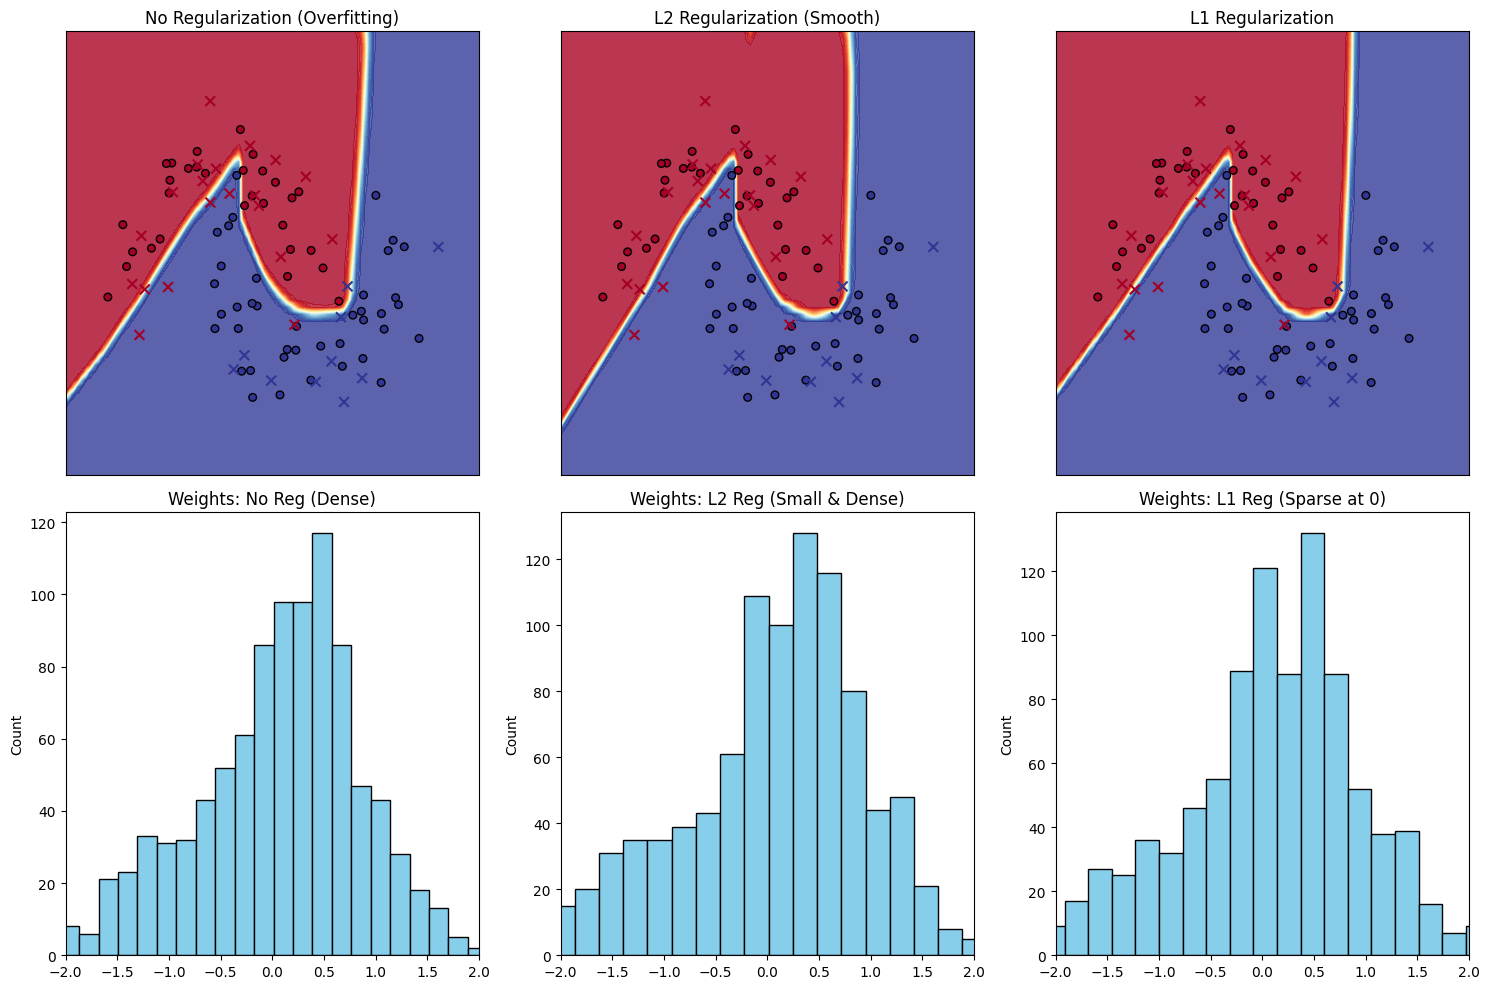


--- 准确率对比 ---
模型          | 训练集 (Train) | 测试集 (Test)
------------------------------------------------
无正则化      | 1.0000       | 0.8000
L2 正则化     | 1.0000       | 0.8000
L1 正则化     | 1.0000       | 0.7667


In [40]:
def plot_decision_boundary(model, ax, title):
    # 生成网格
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))
    
    # 预测网格
    with torch.no_grad():
        grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
        Z = model(grid).numpy().reshape(xx.shape)
        
    ax.contourf(xx, yy, Z, levels=50, cmap='RdYlBu', alpha=0.8)
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='RdYlBu', edgecolors='k', s=30, label='Train')
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='RdYlBu', edgecolors='k', marker='x', s=50, label='Test')
    ax.set_title(title)
    ax.set_xticks(())
    ax.set_yticks(())

def plot_weights_histogram(model, ax, title):
    # 提取第一层隐藏层的权重
    weights = model.fc1.weight.data.numpy().flatten()
    ax.hist(weights, bins=50, color='skyblue', edgecolor='black')
    ax.set_title(title)
    ax.set_xlim(-2, 2) # 固定坐标轴范围以便对比
    ax.set_ylabel('Count')

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 第一行：决策边界 (验证 L2 防过拟合)
plot_decision_boundary(model_none, axes[0, 0], "No Regularization (Overfitting)")
plot_decision_boundary(model_l2, axes[0, 1], "L2 Regularization (Smooth)")
plot_decision_boundary(model_l1, axes[0, 2], "L1 Regularization")

# 第二行：隐藏层权重分布 (验证 L1 稀疏性)
plot_weights_histogram(model_none, axes[1, 0], "Weights: No Reg (Dense)")
plot_weights_histogram(model_l2, axes[1, 1], "Weights: L2 Reg (Small & Dense)")
plot_weights_histogram(model_l1, axes[1, 2], "Weights: L1 Reg (Sparse at 0)")

plt.tight_layout()
plt.show()

# 打印测试集准确率，进一步验证过拟合
def get_acc(model, X, y):
    with torch.no_grad():
        preds = (model(X) > 0.5).float()
        return (preds == y).float().mean().item()

print(f"\n--- 准确率对比 ---")
print(f"模型          | 训练集 (Train) | 测试集 (Test)")
print(f"------------------------------------------------")
print(f"无正则化      | {get_acc(model_none, X_train_t, y_train_t):.4f}       | {get_acc(model_none, X_test_t, y_test_t):.4f}")
print(f"L2 正则化     | {get_acc(model_l2, X_train_t, y_train_t):.4f}       | {get_acc(model_l2, X_test_t, y_test_t):.4f}")
print(f"L1 正则化     | {get_acc(model_l1, X_train_t, y_train_t):.4f}       | {get_acc(model_l1, X_test_t, y_test_t):.4f}")